# Глава 4. Применения векторов

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Корреляция и косинусное сходство

In [7]:
# Данные
N = 30
x_base = np.linspace(0, 10, N) + np.random.randn(N)
y_pos = x_base + np.random.randn(N)
y_neg = -y_pos

# Для круга
theta = np.linspace(0, 2*np.pi, N)
x_circle = np.cos(theta) + np.random.randn(N)/20
y_circle = np.sin(theta) + np.random.randn(N)/20

In [17]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>Positive correlation</b>",
        "<b>Negative correlation</b>",
        "<b>Zero correlation (Noise)</b>",
        "<b>Zero correlation (Circle)</b>"
    ),
    horizontal_spacing=0.15,
    vertical_spacing=0.15
)

def add_scatter(x, y, row, col):
    fig.add_trace(
        go.Scatter(x=x, y=y, mode='markers', marker=dict(color='black', size=8), showlegend=False),
        row=row, col=col
    )

add_scatter(x_base, y_pos, 1, 1)
add_scatter(x_base, y_neg, 1, 2)
add_scatter(np.random.randn(N), np.random.randn(N), 2, 1)
add_scatter(x_circle, y_circle, 2, 2)

for i in range(1, 5):
    axis_name = f"x{i}" if i > 1 else "x"
    yaxis_name = f"yaxis{i}" if i > 1 else "yaxis"

    fig.layout[yaxis_name].update(
        scaleanchor=axis_name,
        scaleratio=1,
        showticklabels=False,
        title="y"
    )

    xaxis_name = f"xaxis{i}" if i > 1 else "xaxis"
    fig.layout[xaxis_name].update(
        showticklabels=False,
        title="x"
    )

fig.update_layout(height=700, width=1200)
fig.show()

## Фильтрация временных рядов и обнаружение признаков

## Кластеризация методом k-средних

## Задания

### 4.1
- Напишите функцию Python, которая на входе принимает два вектора и на выходе выдает два числа: коэффициент корреляции Пирсона и значение косинусного сходства.
- Напишите исходный код, который следует формулам, представленным в данной главе. Не используйте вызовы встроенной в NumPy функции np.corrcoef и встроенной в SciPy функции spatial.distance.cosine.
- Убедитесь, что два значения на выходе идентичны, когда переменные уже центрированы по среднему значению, и различны, когда переменные не центрированы по среднему значению.

**Разбираемся в деталях**
- коэффициент корреляции Пирсона - это
$$p = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$
- косинуснное сходство это -
$$\cos(\theta_{x,y}) = \frac{\alpha}{\|x\| \|y\|} $$

In [2]:
x = np.random.randint(0, 101, size=5)
y = np.random.randint(0, 101, size=5)
# x = np.array([20, 61, 8, 66, 19])
# y = np.array([44, 12, 73, 14, 36])
print(x, y, sep="\n")

[50 54 79 24 51]
[82 52 50 82  9]


In [3]:
def get_coef(x, y):

    # Считаем Пирсона
    x_centering = x - np.mean(x)
    y_centering = y - np.mean(y)

    # Вычисляем числитель
    numerator = np.sum(x_centering * y_centering)

    # Вычисляем знаменатель
    sum_sq_x = np.sum(x_centering**2)
    sum_sq_y = np.sum(y_centering**2)
    denominator = np.sqrt(sum_sq_x) * np.sqrt(sum_sq_y)
    pearson = numerator / denominator

    # Cчитаем косинусное сходство руками
    # Вычисляем числитель
    numerator = x @ y

    # Вычисляем знаменатель
    sum_sq_x = np.sum(x**2)
    sum_sq_y = np.sum(y**2)
    denominator = np.sqrt(sum_sq_x) * np.sqrt(sum_sq_y)
    cosinus = numerator / denominator

    return pearson, cosinus

In [4]:
p, c = get_coef(x, y)
print(
    f"ТЕСТ 1: Нецентрированные данные\n"
    f"x:{x}\n"
    f"y:{y}\n"
    f"pearson: {p}\n"
    f"cosinus: {c}\n"
    f"pearson == cosinus: {np.isclose(p, c)}\n"
)

ТЕСТ 1: Нецентрированные данные
x:[50 54 79 24 51]
y:[82 52 50 82  9]
pearson: -0.38629773025911157
cosinus: 0.7969457424910554
pearson == cosinus: False



In [5]:
x_centered = x - np.mean(x)
y_centered = y - np.mean(y)
p, c = get_coef(x_centered, y_centered)
print(
    f"ТЕСТ 2: Центрированные данные\n"
    f"x:{x}\n"
    f"y:{y}\n"
    f"pearson: {p}\n"
    f"cosinus: {c}\n"
    f"pearson == cosinus: {np.isclose(p, c)}\n"
)

ТЕСТ 2: Центрированные данные
x:[50 54 79 24 51]
y:[82 52 50 82  9]
pearson: -0.3862977302591115
cosinus: -0.38629773025911157
pearson == cosinus: True



In [7]:
# Для визуализации в 2Д возьмем первые 2 компонента каждого вектора
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Оригинальные векторы",
                    "Центрированные векторы")
)

# Функция для рисования вектора-стрелки
def add_vector(vec, name, color, row, col):
    fig.add_trace(go.Scatter(
        x=[0, vec[0]], y=[0, vec[1]],
        mode='lines+markers+text',
        line=dict(color=color, width=4),
        marker=dict(size=10, symbol='arrow-bar-up', angleref="previous"),
        name=name, text=["", name], textposition="top right"
    ), row=row, col=col)

# График 1: Оригиналы
add_vector(x, "x", "red", 1, 1)
add_vector(y, "y", "green", 1, 1)

# График 2: Центрированные
add_vector(x_centered, "x_centered", "red", 1, 2)
add_vector(y_centered, "y_centered", "green", 1, 2)

# Настройки оформления
fig.update_layout(height=500, width=1000, template="plotly_white", showlegend=False)
fig.update_xaxes(zeroline=True, zerolinewidth=2, zerolinecolor='black', range=[-50, 80])
fig.update_yaxes(zeroline=True, zerolinewidth=2, zerolinecolor='black', range=[-50, 80])

fig.show()


In [8]:
# Данные
# v1 = np.array([20, 61, 8, 66, 19])
v1 = x
mean_v1 = np.mean(v1)
v1_c = v1 - mean_v1
indices = np.arange(len(v1))

fig = go.Figure()

# 1. Оригинальное облако (Красное)
fig.add_trace(go.Scatter3d(
    x=indices, y=v1, z=v1,
    mode='markers',
    marker=dict(size=10, color='red', opacity=0.7),
    name=f"Оригинал (Среднее={mean_v1:.1f})"
))

# 2. Центрированное облако (Синее)
fig.add_trace(go.Scatter3d(
    x=indices, y=v1_c, z=v1_c,
    mode='markers',
    marker=dict(size=10, color='blue', opacity=0.7),
    name="Центрированное (Среднее=0)"
))

# 3. Пунктирные линии осей через (0,0,0)
axis_len = 80
# Ось X
fig.add_trace(go.Scatter3d(x=[-1, 5], y=[0, 0], z=[0, 0], mode='lines',
                         line=dict(color='black', width=2, dash='dash'), showlegend=False))
# Ось Y
fig.add_trace(go.Scatter3d(x=[0, 0], y=[-axis_len, axis_len], z=[0, 0], mode='lines',
                         line=dict(color='black', width=2, dash='dash'), showlegend=False))
# Ось Z
fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[-axis_len, axis_len], mode='lines',
                         line=dict(color='black', width=2, dash='dash'), showlegend=False))

# --- НАСТРОЙКА КАМЕРЫ И ОФОРМЛЕНИЯ ---
fig.update_layout(
    title="Визуализация облака данных: Камера в базовой позиции",
    scene=dict(
        xaxis=dict(title='Индекс', range=[-1, 5]),
        yaxis=dict(title='Значение Y', range=[-axis_len, axis_len]),
        zaxis=dict(title='Значение Z', range=[-axis_len, axis_len]),
        # Базовая позиция камеры (x, y, z определяют точку обзора)
        camera=dict(
            up=dict(x=0, y=0, z=1),       # Где "верх"
            center=dict(x=0, y=0, z=0),   # Куда смотрим
            eye=dict(x=1.5, y=1.5, z=1.2) # Откуда смотрим (сбоку-сверху)
        ),
        aspectmode='cube'
    ),
    width=900, height=700,
    margin=dict(l=0, r=0, b=0, t=40),
    template="plotly_white"
)

fig.show()

### 4.2
Давайте продолжим обследовать разницу между корреляцией и косинусным сходством.
- Создайте переменную, содержащую целые числа от 0 до 3, и вторую переменную, равную первой переменной плюс некоторое смещение.
- Затем создайте симуляцию, в которой вы систематически варьируете это смещение между –50 и +50 (то есть на первой итерации симуляции вторая переменная будет равна [–50, –49, –48, –47]).
- В цикле for вычислите корреляцию и косинусное сходство между двумя переменными и сохраните эти результаты.
- Затем постройте линейный график, показывающий, как среднее смещение влияет на корреляцию и косинусное сходство Вы должны суметь воспроизвести рис. 4.4.


**Разбираемся в деталях**
Мы берем один и тот же «сигнал» (числа 0, 1, 2, 3) и начинаем физически двигать его вверх и вниз по оси координат (прибавляя смещение от -50 до +50)
- Гипотеза для Пирсона: Так как форма сигнала не меняется (числа всегда идут «лесенкой» вверх), корреляция должна оставаться идеальной ($1.0$), независимо от того, насколько далеко мы утащили вектор от нуля.
- Гипотеза для Косинуса: Так как косинус смотрит на угол из точки $(0,0)$, при движении вектора угол относительно оригинала будет постоянно меняться.

In [113]:
x = np.array([0, 1, 2, 3])
offsets = np.arange(-50, 51)

pearson_results = []
cosine_results = []

# Симуляция
for offset in offsets:
    y = x + offset # Создаем вторую переменную со смещением

    # Считаем Пирсона
    p = np.corrcoef(x, y)[0, 1]

    # Считаем Косинусное сходство
    # (x @ y) / (||x|| * ||y||)
    c = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

    pearson_results.append(p)
    cosine_results.append(c)

In [114]:
# Визуализация
fig = go.Figure()

# Линия для корреляции Пирсона
fig.add_trace(go.Scatter(
    x=offsets, y=pearson_results,
    mode='lines', name='Pearson Correlation',
    line=dict(color='blue', width=4)
))

# Линия для косинусного сходства
fig.add_trace(go.Scatter(
    x=offsets, y=cosine_results,
    mode='lines', name='Cosine Similarity',
    line=dict(color='red', width=2, dash='dash')
))

fig.update_layout(
    title="Влияние смещения (offset) на метрики сходства",
    xaxis_title="Смещение (Mean Offset)",
    yaxis_title="Значение коэффициента",
    yaxis=dict(range=[-1.1, 1.1]),
    template="plotly_white",
    legend=dict(yanchor="bottom", y=0.01, xanchor="right", x=0.99)
)

fig.show()

In [ ]:
# Почему это ломает Косинус, но не Пирсона?Представь себе луч фонарика, светящий из начала координат $(0,0)$:Для Косинуса: Вектор $x$ — это точка. Когда ты прибавляешь offset, ты двигаешь эту точку по диагонали. Луч фонарика должен постоянно поворачиваться, чтобы следить за этой точкой. Угол меняется — косинус меняется.Для Пирсона: Перед тем как «включить фонарик», Пирсон хватает твой вектор $y$ и силой затаскивает его центр обратно в нулевую точку. Куда бы ты ни передвинул вектор, Пирсон вернет его на место. Поэтому для него вектор $y$ всегда совпадает с $x$. Угол всегда 0 — корреляция всегда 1.

# Этот эксперимент — лучший ответ на вопрос, зачем в нейросетях и статистике делают Batch Normalization или просто вычитают среднее. Без этого косинусное сходство будет выдавать «погоду на Марсе», просто потому что данные сдвинуты от нуля.

### Упражнение 4.3
В Python есть несколько функций, которые вычисляют коэффициент корреляции Пирсона. Одна из них называется pearsonr и находится в модуле stats библиотеки SciPy. Откройте исходный код этого файла и убедитесь, что вы понимаете, как реализация на Python соотносится с формулами, представленными в данной главе.

In [9]:
from scipy import stats

In [10]:
stats.pearsonr(x, y)

PearsonRResult(statistic=np.float64(-0.38629773025911146), pvalue=np.float64(0.5206728076514531))

### 4.4
- Модифицируйте функцию из упражнения 4.2, чтобы вычислить только коэффициент корреляции.
- Затем, в цикле for по 1000 итерациям, сгенерируйте две переменные из 500 случайных чисел и вычислите корреляцию между ними. Засеките время исполнения цикла for.
- Затем повторите, но используя функцию np.corrcoef.

In [15]:
def get_coef(x, y):
    xm = x-np.mean(x)
    ym = y-np.mean(y)
    n  = np.dot(xm,ym)
    d  = np.linalg.norm(xm) * np.linalg.norm(ym)
    return n/d


num_iters  = 1000
var_length =  500

tic = time.time()
for i in range(num_iters):
  x = np.random.randn(var_length,2)
  get_coef(x[:,0],x[:,1])
t1 = time.time() - tic


tic = time.time()
for i in range(num_iters):
  x = np.random.randn(var_length,2)
  stats.pearsonr(x[:,0],x[:,1])
t2 = time.time() - tic


# print the results!
# Note: time() returns seconds, so I multiply by 1000 for ms
print(f'get_coef {t1*1000:.2f} ms')
print(f'stats.pearsonr {t2*1000:.2f} ms')

get_coef 17.24 ms
stats.pearsonr 91.28 ms


### Упражнение 4.5
- Напишите исходный код, который создает эти два временных ряда показанных на рисунке 4.5 А и В
- Напишите цикл for для временных точек в сигнале. В каждый момент времени вычисляйте точечное произведение между ядром и сегментом данных временного ряда, который имеет ту же длину, что и ядро. Вы должны
создать график, который выглядит как график C на рис. 4.5. Обратите внимание, что наш детектор резких изменений вернул 0, когда сигнал был ровным, +1, когда сигнал подскочил вверх, и –1, когда сигнал прыгнул вниз

In [2]:
core = np.array([-1, 1])    # Шаблон
signal = np.zeros(30)       # Сигнал
signal[10:20] = 1
signal += np.random.randn(30) * 0.05

In [9]:
indices = []
results = []
count = len(signal) - len(core) + 1
for i in range(count):
    window = signal[i:i+len(core)]
    detection_value = np.dot(core, window)
    results.append(detection_value)
    indices.append(i)

In [10]:
fig = go.Figure()

# Исходный сигнал
fig.add_trace(go.Scatter(
    x=np.arange(len(signal)), y=signal,
    mode='lines+markers', name='Исходный сигнал',
    line=dict(color='gray', width=2)
))

# Результат детекции
fig.add_trace(go.Scatter(
    x=np.array(indices), y=results,
    mode='lines+markers', name='Результат',
    line=dict(color='red', width=3)
))

fig.update_layout(
    # title="Детектирование всплеска через скалярное произведение",
    xaxis_title="Время",
    yaxis_title="Амплитуда",
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

### 4.6
- Цель будет состоять в том, чтобы сгладить неровный временной ряд. Временной ряд будет состоять из 100 случайных чисел, сгенерированных из гауссова распределения.
- Ядро будет представлять собой функцию в форме колокола, которая аппроксимирует гауссову функцию, определенную как числа [0, .1, .3, .8, 1, .8, .3, .1, 0], но шкалированную так, чтобы сумма по ядру составляла 1

In [80]:
def get_smoothed(core, signal):
    smoothed_signal = np.zeros(len(signal))
    k_len = len(core)
    half_k = k_len // 2 # Чтобы сгладить точку в сигнале, ядро должно лечь на нее центром.

    # Проходим циклом (с учетом отступов, чтобы ядро не вылетело за края)
    for i in range(half_k, N - half_k):
        # Берем окно вокруг текущей точки
        window = signal[i - half_k : i - half_k + k_len]
        # Считаем скалярное произведение
        # Каждое число в window умножается на соответствующий вес из kernel. Центральное число умножается на 1.0, соседи на 0.8, края на 0.0. Все эти результаты складываются.
        smoothed_signal[i] = np.dot(core, window)

    fig = go.Figure()

    # Исходный сигнал
    fig.add_trace(go.Scatter(
        x=np.arange(len(signal)), y=signal,
        mode='lines+markers', name='Исходный сигнал',
        line=dict(color='lightgray', width=2)
    ))

    # Результат детекции
    fig.add_trace(go.Scatter(
        x=np.array(range(1, N+1)), y=smoothed_signal,
        mode='lines+markers', name='Сглаженный сигнал',
        line=dict(color='red', width=2, dash='dash')
    ))

    fig.update_layout(
        title="Детектирование всплеска через скалярное произведение",
        xaxis_title="Время / Индекс",
        yaxis_title="Амплитуда",
        template="plotly_white",
        hovermode="x unified"
    )

    fig.show()


In [81]:
core = np.array([0, .1, .3, .8, 1, .8, .3, .1, 0])
core = core / np.sum(core)

N = 100
signal = np.random.randn(N)

get_smoothed(core, signal)

### 4.7
Замените 1 в центре ядра на –1 и усредните центр ядра. Затем выполните исходный код фильтрации и построения графика повторно. Каким будет результат?

In [82]:
core = np.array([0, .1, .3, .8, -1, .8, .3, .1, 0])
core = core / np.sum(core)

N = 100
signal = np.random.randn(N)

get_smoothed(core, signal)

In [85]:
# Это классический оператор Лапласа. Он идеально находит «переломы» в данных, полностью игнорируя плавные линии.
core = np.array([1,-2, 1])
# core = core / np.sum(core)

N = 100
signal = np.random.randn(N)

get_smoothed(core, signal)

### 4.8

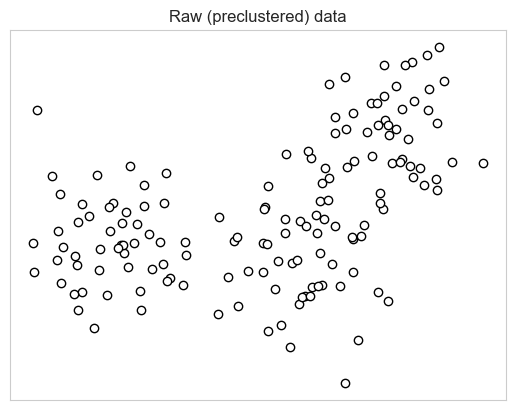

In [5]:
## Create data
nPerClust = 50

# blur around centroid (std units)
blur = 1

# XY centroid locations
A = [  1, 1 ]
B = [ -3, 1 ]
C = [  3, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# concatanate into a matrix
data = np.transpose( np.concatenate((a,b,c),axis=1) )


# plot data
plt.plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
plt.title('Raw (preclustered) data')
plt.xticks([])
plt.yticks([])

plt.show()

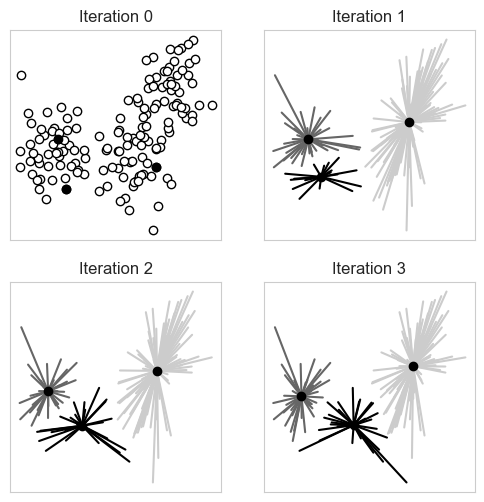

In [9]:

## initialize random cluster centroids
k = 3 # extract three clusters

# random cluster centers (randomly sampled data points)
ridx = np.random.choice(range(len(data)),k,replace=False)
centroids = data[ridx,:]


# setup the figure
fig,axs = plt.subplots(2,2,figsize=(6,6))
axs = axs.flatten()
lineColors = [ [0,0,0],[.4,.4,.4],[.8,.8,.8] ]#'rbm'


# plot data with initial random cluster centroids
axs[0].plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
axs[0].plot(centroids[:,0],centroids[:,1],'ko')
axs[0].set_title('Iteration 0')
axs[0].set_xticks([])
axs[0].set_yticks([])



# loop over iterations
for iteri in range(3):

  # step 1: compute distances
  dists = np.zeros((data.shape[0],k))
  for ci in range(k):
    dists[:,ci] = np.sum((data-centroids[ci,:])**2,axis=1)

  # step 2: assign to group based on minimum distance
  groupidx = np.argmin(dists,axis=1)

  # step 3: recompute centers
  for ki in range(k):
    centroids[ki,:] = [ np.mean(data[groupidx==ki,0]), np.mean(data[groupidx==ki,1]) ]


  # plot data points
  for i in range(len(data)):
    axs[iteri+1].plot([ data[i,0],centroids[groupidx[i],0] ],[ data[i,1],centroids[groupidx[i],1] ],color=lineColors[groupidx[i]])
  axs[iteri+1].plot(centroids[:,0],centroids[:,1],'ko')
  axs[iteri+1].set_title(f'Iteration {iteri+1}')
  axs[iteri+1].set_xticks([])
  axs[iteri+1].set_yticks([])


plt.savefig('Figure_04_03.png',dpi=300)
plt.show()